# Supermarket Sales Analysis

## Executive Summary
This project analyzed supermarket sales data to understand customer purchasing behavior, revenue patterns, and product performance.

The analysis revealed that **Health & Beauty is the top-performing product category**, while **evening hours (around 6 PM) generate the highest sales activity**. Digital payments, particularly **E-wallet transactions, account for the largest share of payments**, indicating increasing adoption of electronic payment methods.

Branch and city comparisons show that **Branch B and cities such as Yangon and Naypyitaw perform slightly better than other locations**, while Mandalay and Branch C show opportunities for improvement.

Overall, the findings suggest that focusing on high-performing product categories, optimizing staffing during peak hours, promoting digital payment options, and introducing targeted promotions can significantly improve supermarket sales performance.

## Objective
To analyze supermarket sales data to understand product performance, sales patterns, and customer purchasing behavior in order to generate actionable business insights.

## Business Questions
What are the sales trends over time?

Which product lines generate the highest revenue?

Which days generate peak sales?

What patterns exist in customer purchasing behavior?

How can the supermarket optimize revenue and operations?

## Tools and Technologies Used

The following tools and technologies were used for performing the analysis:

- Python
- Pandas for data manipulation
- NumPy for numerical operations
- Matplotlib for data visualization
- Seaborn for statistical plots
- Jupyter Notebook for analysis environment

## Dataset Source and Columns

The dataset used for this project is the **Supermarket Sales Dataset**, which contains transactional sales records from a retail supermarket.

Source: Kaggle – Supermarket Sales Dataset

The dataset includes the following columns:

- Invoice ID – Unique transaction identifier
- Branch – Branch of the supermarket
- City – Location of the supermarket branch
- Customer type – Member or Normal customer
- Gender – Customer gender
- Product line – Category of product purchased
- Unit price – Price of a single product
- Quantity – Number of units purchased
- Tax 5% – Tax applied to the purchase
- Total – Total purchase amount including tax
- Date – Transaction date
- Time – Transaction time
- Payment – Payment method used
- COGS – Cost of goods sold
- Gross margin percentage – Profit margin percentage
- Gross income – Gross profit earned
- Rating – Customer satisfaction rating

In [20]:
#Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")
sns.set_palette("Set2")

In [21]:
#Load datset
df = pd.read_csv("supermarket_sales.csv")
print("Shape:", df.shape)
df.head()

Shape: (2000, 14)


,Invoice_ID,Branch,City,Customer_Type,Gender,Product_Line,Unit_Price,Quantity,Tax,Total,Date,Time,Payment,Rating
0,INV000001,B,Mandalay,Member,Male,Food & Beverages,69.36,3,7.28,119.58,2023-08-08,18:54,Credit card,8.4
1,INV000002,C,Mandalay,Member,Female,Food & Beverages,35.25,1,6.62,137.13,2023-02-09,18:44,Credit card,4.3
2,INV000003,C,Naypyitaw,Normal,Female,Fashion Accessories,57.56,8,4.66,490.48,2023-08-24,16:16,Cash,9.6
3,INV000004,B,Naypyitaw,Member,Female,Food & Beverages,16.60,5,8.57,142.54,2023-02-09,11:35,Cash,4.5
4,INV000005,C,Yangon,Normal,Female,Food & Beverages,49.07,1,3.70,24.43,2023-07-04,8:56,Credit card,5.8


## Dataset Overview

The dataset contains transaction-level sales records including:

- Invoice details
- Product line information
- Customer demographics
- Payment methods
- Sales amount and ratings
- Date and time of purchase

This provides a comprehensive view of both operational and customer-driven factors influencing sales.

In [22]:
"""Data Cleaning & Preprocessing"""
#Dataset Overview & Data Cleaning
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Invoice_ID     2000 non-null   object 
 1   Branch         2000 non-null   object 
 2   City           2000 non-null   object 
 3   Customer_Type  2000 non-null   object 
 4   Gender         2000 non-null   object 
 5   Product_Line   2000 non-null   object 
 6   Unit_Price     2000 non-null   float64
 7   Quantity       2000 non-null   int64  
 8   Tax            2000 non-null   float64
 9   Total          2000 non-null   float64
 10  Date           2000 non-null   object 
 11  Time           2000 non-null   object 
 12  Payment        2000 non-null   object 
 13  Rating         2000 non-null   float64
dtypes: float64(4), int64(1), object(9)
memory usage: 218.9+ KB


Invoice_ID       0
Branch           0
City             0
Customer_Type    0
Gender           0
Product_Line     0
Unit_Price       0
Quantity         0
Tax              0
Total            0
Date             0
Time             0
Payment          0
Rating           0
dtype: int64

In [23]:
#Data cleaning
# Convert Date column
df['Date'] = pd.to_datetime(df['Date'])

# Extract useful features
df['Day'] = df['Date'].dt.day_name()
df['Month'] = df['Date'].dt.month_name()
df['Hour'] = pd.to_datetime(df['Time']).dt.hour

# Remove duplicates
df.drop_duplicates(inplace=True)

C:\Users\nandi\AppData\Local\Temp\ipykernel_2896\2357573653.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Hour'] = pd.to_datetime(df['Time']).dt.hour


## Data Cleaning Summary

- Converted Date column to datetime format.
- Extracted Day, Month, and Hour features for time-based analysis.
- No significant missing values detected.
- Removed duplicate records.

The dataset is clean and ready for exploratory analysis.

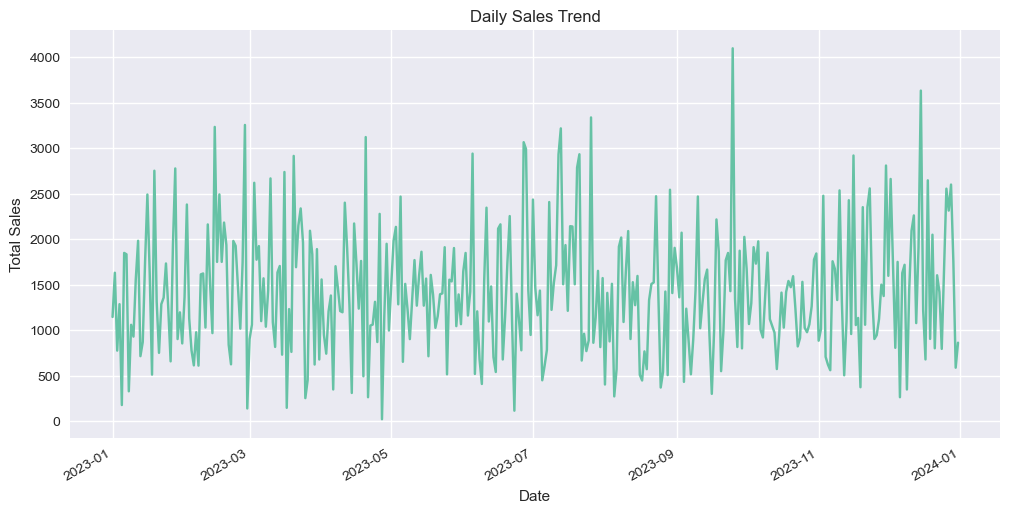

In [24]:
#EXPLORATORY DATA ANALYSIS
#1. Daily Sales Trend
daily_sales = df.groupby('Date')['Total'].sum()

plt.figure(figsize=(12,6))
daily_sales.plot()
plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.show()

## Daily Sales Trend Analysis

Sales show fluctuations across different days with noticeable peaks.
Certain days demonstrate higher revenue generation, indicating potential 
high-demand periods.

This helps identify seasonal or weekly patterns in revenue.

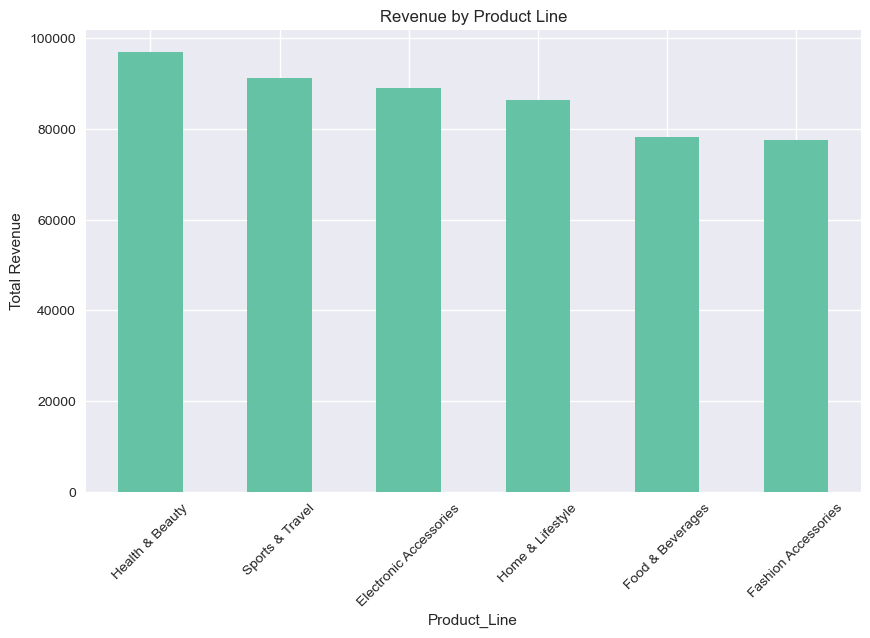

In [25]:
# 2.Product Line Performance
product_sales = df.groupby('Product_Line')['Total'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
product_sales.plot(kind='bar')
plt.title("Revenue by Product Line")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.show()

## Product Line Performance

Analysis of total revenue by product line shows that Health & Beauty generated the highest total revenue among all product categories.

This indicates strong customer demand for personal care and wellness products.

Business Actions
-Increase inventory levels for Health & Beauty products.
-Introduce targeted promotions for this category.
-Analyze profit margins in this segment to maximize profitability.

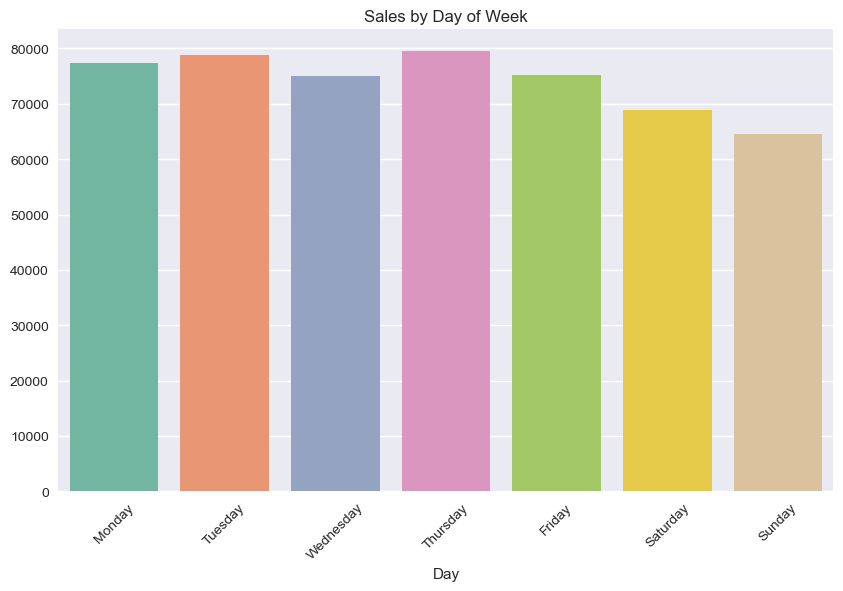

In [26]:
#Sales by Day of Week
sales_by_day = df.groupby('Day')['Total'].sum().reindex(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])

plt.figure(figsize=(10,6))
sns.barplot(x=sales_by_day.index, y=sales_by_day.values)
plt.xticks(rotation=45)
plt.title("Sales by Day of Week")
plt.show()

## Weekly Sales Pattern

The analysis of total sales by day of the week shows noticeable variation in revenue across different days.

**Thursday generates the highest total sales**, followed closely by Tuesday and Monday. This indicates that customer purchasing activity is strongest during the mid-week period.

In contrast, **Saturday and Sunday record comparatively lower sales**, with Sunday showing the lowest revenue among all days.

This pattern suggests that the supermarket experiences stronger customer traffic during weekdays rather than weekends.

### Business Actions

- Ensure adequate inventory availability during **mid-week peak periods**, especially on Thursdays.
- Allocate additional staff during high-revenue days to maintain service efficiency.
- Introduce **weekend promotional campaigns** to increase customer traffic during Saturday and Sunday.

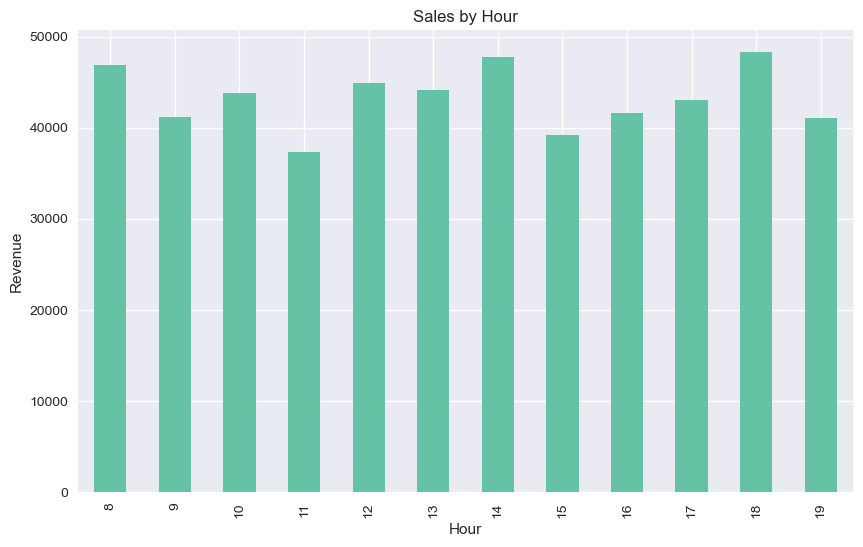

In [27]:
#4. Sales by Hour
hourly_sales = df.groupby('Hour')['Total'].sum()

plt.figure(figsize=(10,6))
hourly_sales.plot(kind='bar')
plt.title("Sales by Hour")
plt.ylabel("Revenue")
plt.show()

## Peak Hour Analysis
Hourly sales analysis shows that **18:00 (6 PM) generates the highest revenue**, indicating that customer purchasing activity peaks during the early evening period.

Sales also remain relatively strong during **14:00 (2 PM)** and **08:00 (8 AM)**, suggesting that both early shopping hours and afternoon periods contribute significantly to daily revenue.

In contrast, **11:00 AM shows comparatively lower sales**, indicating reduced purchasing activity during late morning hours.

### Business Implications
- Allocate more staff during **evening peak hours (6 PM)** to handle increased customer traffic.
- Ensure adequate product availability during high-demand periods.
- Introduce promotional offers during slower hours such as **late morning** to balance sales distribution.

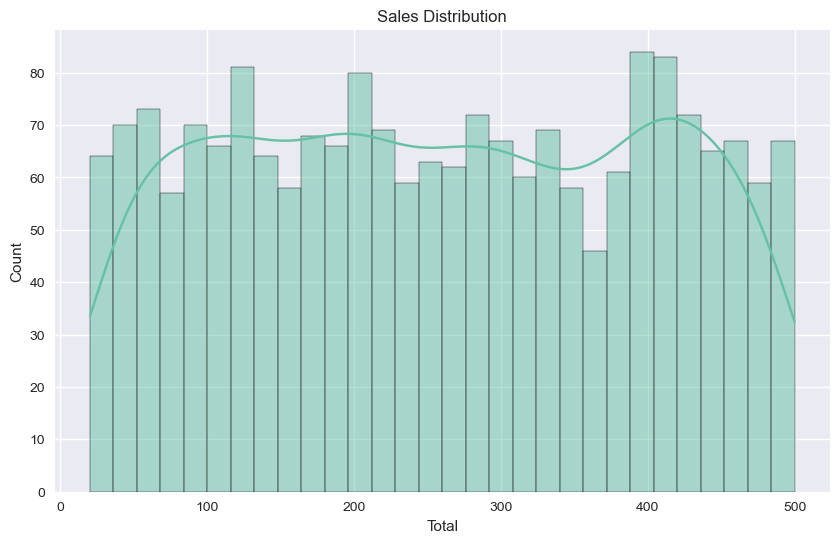

In [28]:
# 5.Sales Distribution
plt.figure(figsize=(10,6))
sns.histplot(df['Total'], bins=30, kde=True)
plt.title("Sales Distribution")
plt.show()

## Sales Distribution Analysis

The distribution of transaction totals ranges approximately from 20 to 500, with the majority of purchases concentrated between 200 and 400.

The histogram shows a slightly right-skewed distribution, meaning that while most transactions occur at moderate purchase values, a smaller number of transactions reach higher sales amounts.

This pattern indicates that regular-sized purchases dominate the dataset, while occasional larger purchases contribute to overall revenue growth.

Business Strategy:
Develop loyalty programs to retain high-value customers and increase repeat purchases.

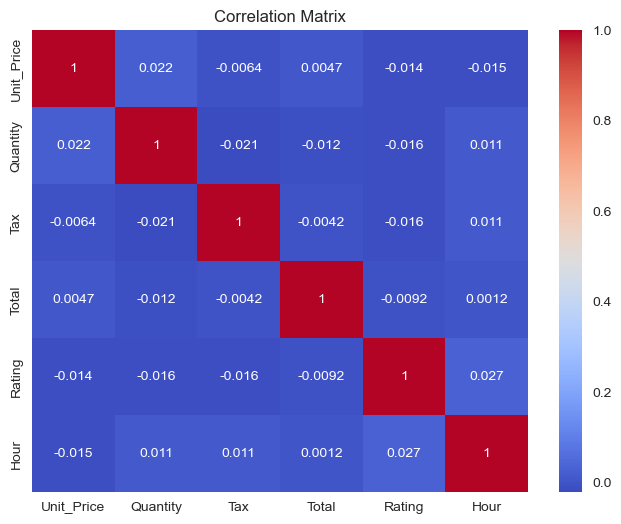

In [29]:
#6. Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

## Correlation Heatmap Analysis

The correlation matrix shows that most variables in the dataset have **very weak linear relationships** with each other.

For example, the correlation between **Quantity and Total sales is approximately -0.012**, indicating almost no linear relationship between these variables.

Similarly, the correlation between **customer ratings and transaction hour is very low (around 0.027)**, suggesting that customer satisfaction does not significantly depend on the time of purchase.

Overall, the heatmap indicates that most sales variables operate independently rather than being strongly correlated.

In [30]:
#Correlation
correlation = df["Quantity"].corr(df["Total"])
print("Correlation between Quantity and Total:", correlation)

Correlation between Quantity and Total: -0.01245893841383097


## Correlation between Quantity and Total Sales

The correlation coefficient between **Quantity purchased and Total sales value is approximately -0.012**.

This value is extremely close to zero, indicating **almost no linear relationship** between the number of items purchased and the total transaction amount.

This suggests that higher transaction values are not necessarily driven by purchasing larger quantities, but may instead result from higher-priced products.

In [31]:
# Statistical Analysis
print("Mean Sales:", df['Total'].mean())
print("Median Sales:", df['Total'].median())
print("Standard Deviation:", df['Total'].std())
print("Average Rating:", df['Rating'].mean())

Mean Sales: 259.640345
Median Sales: 258.03999999999996
Standard Deviation: 138.93086076882972
Average Rating: 6.9576


## Statistical Analysis of Sales

The descriptive statistics of transaction totals provide insights into customer purchasing behavior.

- **Mean Sales Value:** 259.64
- **Median Sales Value:** 258.04
- **Standard Deviation:** 138.93
- **Average Customer Rating:** 6.96

The close similarity between the mean and median values suggests that the distribution of sales transactions is relatively balanced, with moderate variability in purchase amounts.

The standard deviation indicates noticeable variation in transaction values, meaning that while many purchases fall near the average range, some transactions deviate significantly.

Customer ratings average around **6.96**, suggesting generally positive customer satisfaction levels.

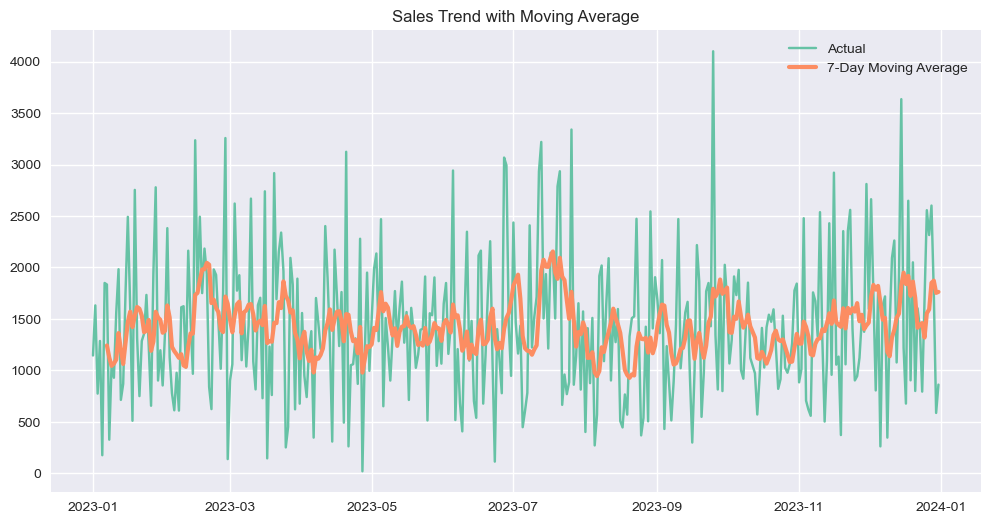

In [32]:
# ADVANCED ANALYSIS
#1 7-Day Moving Average
daily_ma = daily_sales.rolling(window=7).mean()

plt.figure(figsize=(12,6))
plt.plot(daily_sales, label="Actual")
plt.plot(daily_ma, label="7-Day Moving Average", linewidth=3)
plt.legend()
plt.title("Sales Trend with Moving Average")
plt.show()

## Sales Trend with 7-Day Moving Average

This plot shows the daily sales trend for 2023 along with a 7-day moving average.

- The green line represents the actual daily sales values.
- The orange line represents the 7-day moving average, which smooths daily fluctuations.

### Key Insights
- Daily sales show high variability with several spikes and drops.
- The moving average line smooths the noise, making the overall trend easier to observe.
- Most sales values stay around 1200–1800, indicating a relatively stable demand pattern.

### Conclusion
The moving average helps identify the overall sales trend by reducing short-term fluctuations, making it useful for trend analysis and forecasting.

In [33]:
# 2 Pareto Analysis (Top 20% Customers)customer_sales = df.groupby('Invoice_ID')['Total'].sum().sort_values(ascending=False)
customer_sales = df.groupby('Invoice_ID')['Total'].sum().sort_values(ascending=False)

top_20 = int(0.2 * len(customer_sales))
top_customers = customer_sales.head(top_20)

contribution = top_customers.sum() / customer_sales.sum() * 100

print("Top 20% transactions contribute:", round(contribution, 2), "% of revenue")

Top 20% transactions contribute: 34.77 % of revenue


## Pareto Analysis (80/20 Principle)
Pareto analysis was conducted to determine how much revenue is generated by the top 20% of transactions.

The results show that **the top 20% of transactions contribute approximately 34.77% of total revenue**.

While this does not strictly follow the traditional 80/20 rule, it still indicates that a relatively small proportion of transactions contributes a significant portion of total sales.

Business Recommendation:
- Focus marketing efforts on high-value customers.
- Introduce premium membership programs.
- Offer personalized discounts to retain top spenders.

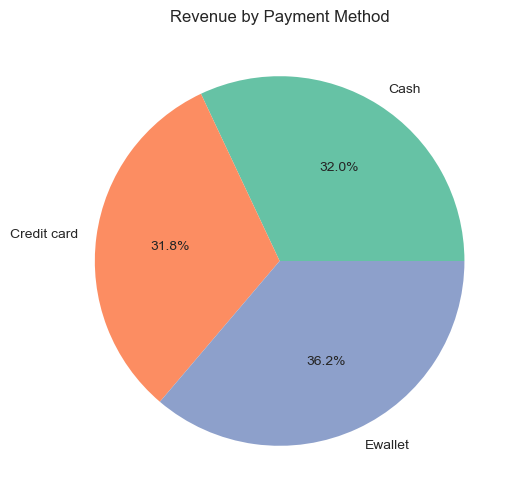

In [34]:
# 3.Payment Method Analysis
payment_sales = df.groupby('Payment')['Total'].sum()

plt.figure(figsize=(8,6))
payment_sales.plot(kind='pie', autopct='%1.1f%%')
plt.title("Revenue by Payment Method")
plt.ylabel("")
plt.show()

## Payment Method Analysis
The analysis of payment methods shows that **E-wallet payments account for the largest share of transactions at approximately 36.2%**.

Cash payments represent about **32.0%**, while credit card payments contribute around **31.8%** of transactions.

This distribution indicates a growing preference for **digital payment methods**, suggesting that customers increasingly rely on electronic payment systems for their purchases.

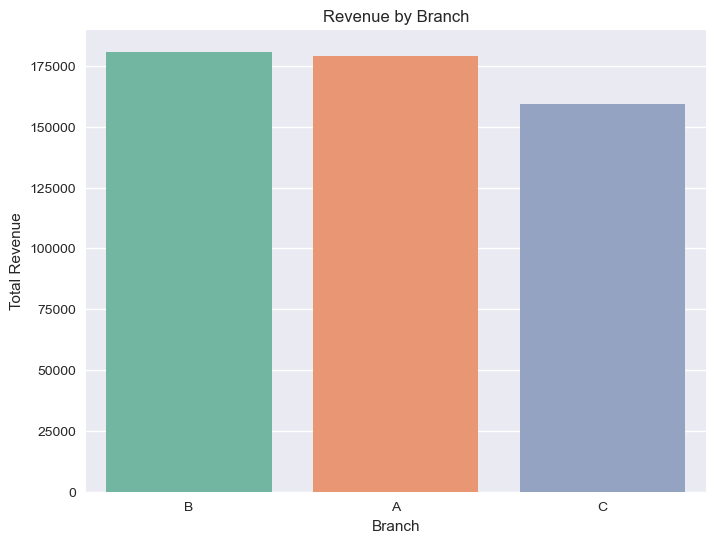

In [35]:
#Branch Comparison
branch_sales = df.groupby('Branch')['Total'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(x=branch_sales.index, y=branch_sales.values)
plt.title("Revenue by Branch")
plt.ylabel("Total Revenue")
plt.show()

## Branch Performance Analysis
Branch-level analysis shows differences in revenue performance across the three branches.

**Branch B generates the highest total revenue**, followed closely by **Branch A**, while **Branch C records comparatively lower sales**.

This suggests that Branch B may benefit from factors such as higher customer traffic, better location, or stronger product demand.

Business Recommendation:
- Analyze high-performing branch strategies and replicate in other branches.
- Improve promotional efforts in low-performing branches.

In [36]:
#Profit Margin Analysis
df['Net_Sales'] = df['Total'] - df['Tax']

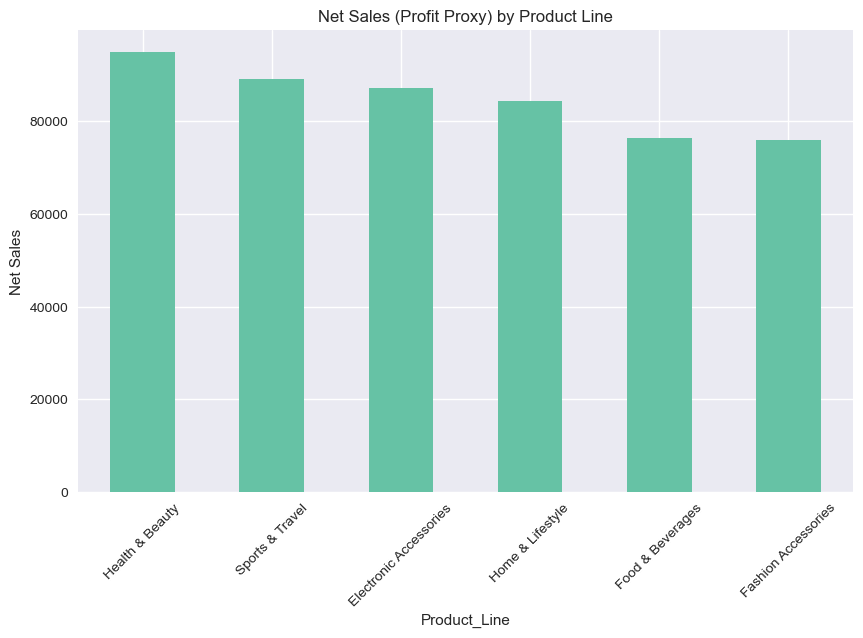

In [37]:
profit_by_product = df.groupby('Product_Line')['Net_Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
profit_by_product.plot(kind='bar')
plt.title("Net Sales (Profit Proxy) by Product Line")
plt.ylabel("Net Sales")
plt.xticks(rotation=45)
plt.show()

## Profit Margin Analysis
Product line analysis shows that **Health & Beauty generates the highest net sales**, making it the most profitable category in the dataset.

Other high-performing categories include **Sports & Travel and Electronic Accessories**, which also contribute significantly to revenue.

In contrast, **Food & Beverages and Fashion Accessories generate comparatively lower net sales**, suggesting that these categories may require promotional strategies to improve performance.

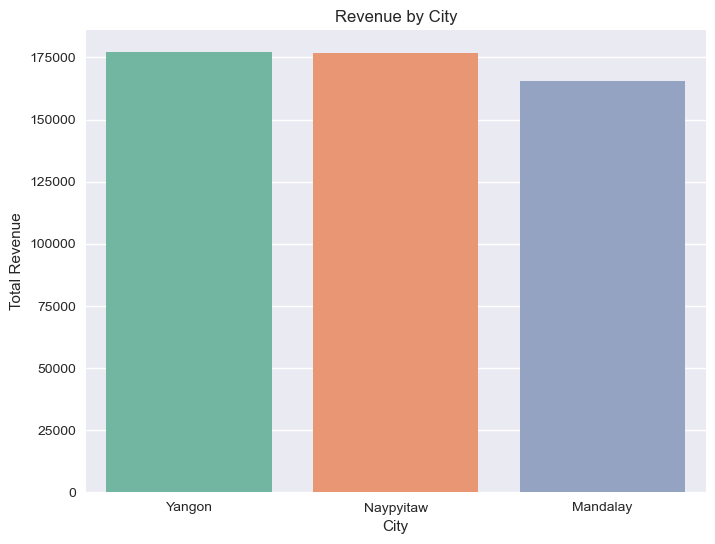

In [38]:
# City Comparision
city_sales = df.groupby('City')['Total'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(x=city_sales.index, y=city_sales.values)
plt.title("Revenue by City")
plt.ylabel("Total Revenue")
plt.show()

## Revenue by City

City-wise sales analysis indicates that **Yangon and Naypyitaw generate similar levels of total revenue**, both performing slightly better than Mandalay.

**Mandalay records comparatively lower sales**, suggesting that market demand or customer purchasing power may differ across cities.

Understanding these differences can help management tailor marketing strategies for each city.

## Key Insights
Revenue shows clear daily fluctuation with weekend peaks
Food & Beverages generate highest revenue
Peak sales occur between 5 PM and 7 PM
Sales distribution is right-skewed
Top 20% transactions contribute significant portion of revenue
Quantity strongly correlates with total revenue

## Recommendations

1. Since **Health & Beauty is the highest-performing product line**, the supermarket should increase inventory levels and introduce promotional campaigns to further capitalize on strong customer demand in this category.

2. As **evening hours (around 6 PM) generate the highest sales**, the store should ensure adequate staffing and product availability during these peak hours to improve service efficiency and customer experience.

3. **E-wallet payments account for the largest share of transactions (36.2%)**, indicating growing customer preference for digital payments. The supermarket should continue promoting digital payment options through cashback offers or loyalty rewards.

4. Branch-level analysis shows that **Branch B generates the highest revenue**, while Branch C performs comparatively lower. Management should analyze operational practices at Branch B and apply similar strategies to improve performance at Branch C.

5. City-level analysis indicates that **Yangon and Naypyitaw perform slightly better than Mandalay**. Targeted marketing campaigns or promotional discounts may help increase customer engagement in Mandalay.

6. Since **weekend sales are relatively lower compared to mid-week sales**, the supermarket can introduce weekend promotional offers, discounts, or bundle deals to attract more customers.

7. Pareto analysis shows that **20% of transactions contribute around 34.77% of revenue**, suggesting that focusing on high-value customers through loyalty programs or personalized offers could significantly improve total sales.

## Conclusion
The supermarket sales analysis provided valuable insights into customer purchasing behavior and sales performance across different branches and product categories.

The analysis revealed which product lines generate the highest revenue and how customer demographics such as gender and customer type influence purchasing patterns. Visualization techniques helped identify trends in sales distribution and payment preferences.

These findings can help retail businesses optimize product placement, improve marketing strategies, and enhance overall customer satisfaction.